<a href="https://colab.research.google.com/github/sachini86/MyResearch/blob/main/Xceptionmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# After running this cell, click the link,
# sign in to your Google account, copy the code, paste it here
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


In [2]:
# Install Kaggle API
!pip install -q kaggle

# Upload your kaggle.json API key
from google.colab import files
files.upload()  # ← click this, select your kaggle.json file

# Move it to the right place
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d kaveendahelitha40/cinnamon-quill-grades-classification-image-dataset
!unzip -q cinnamon-quill-grades-classification-image-dataset.zip -d /content/kaggle_dataset

# Check what was downloaded
import os
for item in os.listdir('/content/kaggle_dataset'):
    print(item)

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kaveendahelitha40/cinnamon-quill-grades-classification-image-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 5.52G/5.52G [01:18<00:00, 75.8MB/s]

cinnamon quills images


In [3]:
import os

# See what's inside
for root, dirs, files in os.walk('/content/kaggle_dataset'):
    level = root.replace('/content/kaggle_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show 2 levels deep
        for f in files[:3]:  # show first 3 files as sample
            print(f'{indent}  {f}')

kaggle_dataset/
  cinnamon quills images/
    C5/
    C5 Special/
    C4/
    Alba/


In [4]:
import os
import shutil

YOUR_DATA   = '/content/drive/MyDrive'
KAGGLE_DATA = '/content/kaggle_dataset/cinnamon quills images'

CLASSES_YOUR     = ['Alba', 'C4', 'C5', 'C5-special']
CLASSES_KAGGLE   = ['Alba', 'C4', 'C5', 'C5 Special']
CLASSES_STANDARD = ['alba', 'c4', 'c5', 'c5_special']

WORK_DIR    = '/content/cinnamon_work'
MERGED_DATA = '/content/cinnamon_work/merged_dataset'
SPLIT_DATA  = '/content/cinnamon_work/split_dataset'
os.makedirs(WORK_DIR, exist_ok=True)

def count_images_recursive(folder):
    """Counts all images in folder AND all subfolders"""
    count = 0
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                count += 1
    return count

# Verify counts
for yours, kaggle in zip(CLASSES_YOUR, CLASSES_KAGGLE):
    p1 = os.path.join(YOUR_DATA, yours)
    p2 = os.path.join(KAGGLE_DATA, kaggle)
    c1 = count_images_recursive(p1) if os.path.exists(p1) else 0
    c2 = count_images_recursive(p2) if os.path.exists(p2) else 0
    print(f'{yours:12s} → yours: {c1:4d}  kaggle: {c2:4d}  total: {c1+c2:4d}')

Alba         → yours:  250  kaggle:  173  total:  423
C4           → yours:   95  kaggle:  215  total:  310
C5           → yours:  115  kaggle:  199  total:  314
C5-special   → yours:  160  kaggle:  334  total:  494


In [5]:
# Install converter
!pip install -q pillow-heif

from pillow_heif import register_heif_opener
from PIL import Image
import os

register_heif_opener()

def convert_heic_to_jpg(base_path, classes):
    for cls in classes:
        cls_path = os.path.join(base_path, cls)
        if not os.path.exists(cls_path):
            continue
        converted = 0
        for root, dirs, files in os.walk(cls_path):
            for fname in files:
                if fname.upper().endswith('.HEIC'):
                    src = os.path.join(root, fname)
                    dst = src.replace('.HEIC', '.jpg').replace('.heic', '.jpg')
                    try:
                        img = Image.open(src)
                        img.save(dst, 'JPEG', quality=95)
                        converted += 1
                    except Exception as e:
                        print(f'  Failed: {fname} — {e}')
        print(f'{cls} → {converted} files converted')

convert_heic_to_jpg('/content/drive/MyDrive', ['C4', 'C5', 'C5-special'])
print('Done! Now re-run the count cell.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 35.7 MB/s eta 0:00:00
C4 → 95 files converted
C5 → 115 files converted
C5-special → 160 files converted
Done! Now re-run the count cell.


In [6]:
for yours, kaggle in zip(CLASSES_YOUR, CLASSES_KAGGLE):
    p1 = os.path.join(YOUR_DATA, yours)
    p2 = os.path.join(KAGGLE_DATA, kaggle)
    c1 = count_images_recursive(p1) if os.path.exists(p1) else 0
    c2 = count_images_recursive(p2) if os.path.exists(p2) else 0
    print(f'{yours:12s} → yours: {c1:4d}  kaggle: {c2:4d}  total: {c1+c2:4d}')

Alba         → yours:  250  kaggle:  173  total:  423
C4           → yours:   95  kaggle:  215  total:  310
C5           → yours:  115  kaggle:  199  total:  314
C5-special   → yours:  160  kaggle:  334  total:  494


In [7]:
!pip install -q scikit-learn matplotlib seaborn

import shutil, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [8]:
# New merging step

import shutil

MERGED_DATA = '/content/merged_dataset'
SPLIT_DATA  = '/content/split_dataset'
SAVE_DIR    = '/content/drive/MyDrive/cinnamon_results'
CLASSES     = ['alba', 'c4', 'c5', 'c5_special']

os.makedirs(SAVE_DIR, exist_ok=True)

your_map   = {
    'alba':       'Alba',
    'c4':         'C4',
    'c5':         'C5',
    'c5_special': 'C5-special'   # hyphen — matches your Drive
}

kaggle_map = {
    'alba':       'Alba',
    'c4':         'C4',
    'c5':         'C5',
    'c5_special': 'C5 Special'   # space + capital S — matches Kaggle
}

views = ['Top', 'Bottom', 'Left', 'Right', 'Cross']

print(f'{"Grade":<14} {"Yours":>6} {"Kaggle":>8} {"Total":>7}')
print('-' * 40)

for cls in CLASSES:
    out_dir = os.path.join(MERGED_DATA, cls)
    os.makedirs(out_dir, exist_ok=True)
    count = 0

    # ── YOUR images (view subfolders) ──────────────────────────────
    your_folder = f'/content/drive/MyDrive/{your_map[cls]}'
    your_count  = 0
    for view in views:
        vpath = os.path.join(your_folder, view)
        if not os.path.exists(vpath):
            continue
        for fname in os.listdir(vpath):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(
                    os.path.join(vpath, fname),
                    os.path.join(out_dir, f'yours_{view}_{count:05d}_{fname}')
                )
                count      += 1
                your_count += 1

    # ── KAGGLE images (flat folder) ────────────────────────────────
    kaggle_folder = os.path.join(KAGGLE_DATA, kaggle_map[cls])
    kaggle_count  = 0

    # ↓ debug print — remove after confirming it works
    print(f'  [debug] looking for kaggle folder: {kaggle_folder}  exists={os.path.exists(kaggle_folder)}')

    if os.path.exists(kaggle_folder):
        for fname in os.listdir(kaggle_folder):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(
                    os.path.join(kaggle_folder, fname),
                    os.path.join(out_dir, f'kaggle_{count:05d}_{fname}')
                )
                count        += 1
                kaggle_count += 1

    print(f'{cls:<14} {your_count:>6} {kaggle_count:>8} {count:>7}')

print('\n✅ Merge complete!')

Grade           Yours   Kaggle   Total
----------------------------------------
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/Alba  exists=True
alba              250      173     423
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/C4  exists=True
c4                 95      215     310
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/C5  exists=True
c5                115      199     314
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/C5 Special  exists=True
c5_special        160      334     494

✅ Merge complete!


In [9]:
# Cell split 70/15/15

import random

def split_dataset(merged_path, output_path, classes, train_r=0.70, val_r=0.15):
    random.seed(42)
    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

    print(f'{"Grade":<14} {"Train":>6} {"Val":>6} {"Test":>6} {"Total":>7}')
    print('-' * 44)
    for cls in classes:
        src_dir = os.path.join(merged_path, cls)
        files   = [f for f in os.listdir(src_dir)
                   if f.lower().endswith(('.jpg','.jpeg','.png'))]
        random.shuffle(files)
        n       = len(files)
        n_train = int(n * train_r)
        n_val   = int(n * val_r)
        for split_name, flist in [('train', files[:n_train]),
                                   ('val',   files[n_train:n_train+n_val]),
                                   ('test',  files[n_train+n_val:])]:
            for fname in flist:
                shutil.copy2(
                    os.path.join(src_dir, fname),
                    os.path.join(output_path, split_name, cls, fname)
                )
        print(f'{cls:<14} {n_train:>6} {n_val:>6} {n-n_train-n_val:>6} {n:>7}')

split_dataset(MERGED_DATA, SPLIT_DATA, CLASSES)
print('\n✅ Split complete!')

Grade           Train    Val   Test   Total
--------------------------------------------
alba              296     63     64     423
c4                217     46     47     310
c5                219     47     48     314
c5_special        345     74     75     494

✅ Split complete!


Found 1077 images belonging to 4 classes.
Found 230 images belonging to 4 classes.
Found 234 images belonging to 4 classes.
Train: 1077  Val: 230  Test: 234
Classes: {'alba': 0, 'c4': 1, 'c5': 2, 'c5_special': 3}

Class weights:
  alba          : 0.910
  c4            : 1.241
  c5            : 1.229
  c5_special    : 0.780


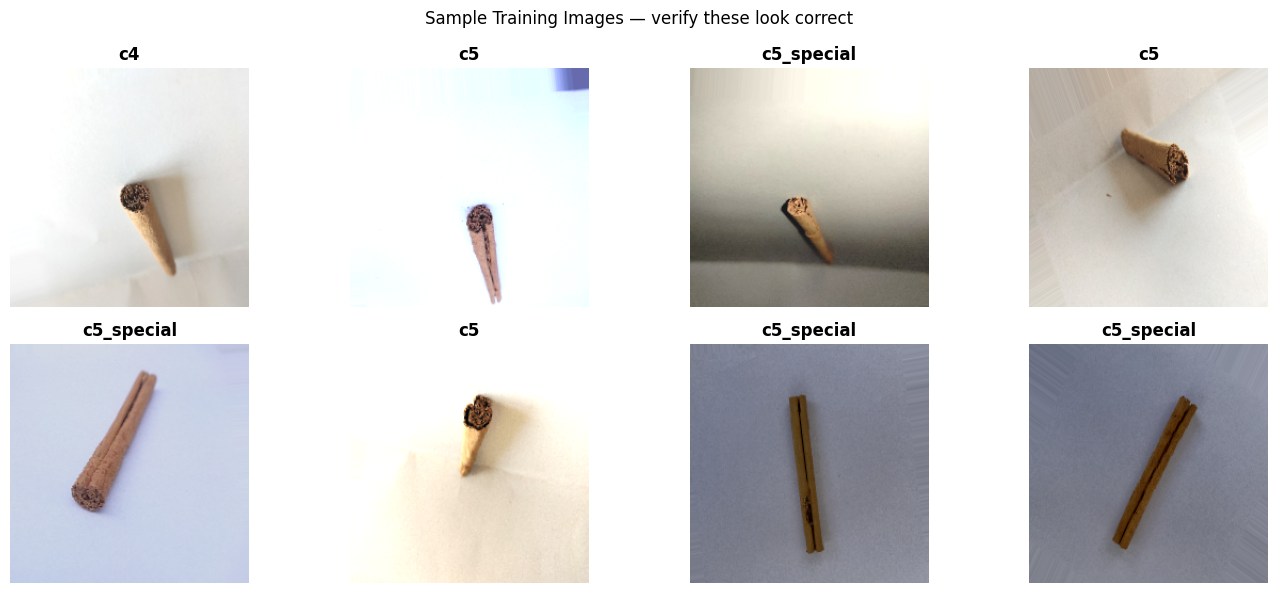

✅ Generators ready — check the images above look correct before training!


In [10]:
# Generators + class weights:

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_gen    = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=20.0,
    fill_mode='nearest'
)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'train'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=CLASSES, class_mode='categorical',
    shuffle=True, seed=42
)
val_data = val_test_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'val'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=CLASSES, class_mode='categorical',
    shuffle=False
)
test_data = val_test_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'test'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=CLASSES, class_mode='categorical',
    shuffle=False
)

cw_array     = compute_class_weight('balanced',
                   classes=np.unique(train_data.classes),
                   y=train_data.classes)
class_weights = dict(enumerate(cw_array))

print(f'Train: {train_data.samples}  Val: {val_data.samples}  Test: {test_data.samples}')
print(f'Classes: {train_data.class_indices}')
print('\nClass weights:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:<14}: {cw_array[i]:.3f}')

# Sanity check — show sample images
imgs, lbls = next(iter(train_data))
fig, axes  = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    ax.set_title(CLASSES[np.argmax(lbls[i])], fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Training Images — verify these look correct', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_images.png', dpi=100)
plt.show()
print('✅ Generators ready — check the images above look correct before training!')

In [11]:
from tensorflow.keras.applications import DenseNet121, ResNet50V2, MobileNetV3Small, InceptionV3
from sklearn.metrics import accuracy_score
import gc

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
results    = {}

def build_model(base_fn, name, input_shape=(*IMG_SIZE, 3)):
    base           = base_fn(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False
    inputs  = tf.keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    model   = models.Model(inputs, outputs)
    print(f'✅ {name} built — {model.count_params():,} parameters')
    return model, base

def train_model(model, base, name, phase1_epochs=10, phase2_epochs=20, finetune_pct=0.4):
    cb = [
        EarlyStopping(monitor='val_accuracy', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{SAVE_DIR}/best_{name}.h5',
                        monitor='val_accuracy', save_best_only=True, verbose=1)
    ]
    print(f'\n{"="*50}')
    print(f'TRAINING: {name}')
    print(f'{"="*50}')
    print(f'--- Phase 1: Training head ({phase1_epochs} epochs) ---')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    h1 = model.fit(train_data, epochs=phase1_epochs,
                   validation_data=val_data,
                   class_weight=class_weights, callbacks=cb, verbose=1)

    print(f'\nBest val accuracy Phase 1: {max(h1.history["val_accuracy"]):.4f}')
    print(f'\n--- Phase 2: Fine-tuning top {int(finetune_pct*100)}% layers ---')
    base.trainable = True
    freeze_until   = int(len(base.layers) * (1 - finetune_pct))
    for layer in base.layers[:freeze_until]:
        layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    h2 = model.fit(train_data, epochs=phase2_epochs,
                   validation_data=val_data,
                   class_weight=class_weights, callbacks=cb, verbose=1)
    return h1, h2

def evaluate_model(model, name, h1, h2):
    test_data.reset()
    y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)
    y_true = test_data.classes
    labels = list(test_data.class_indices.keys())
    acc    = accuracy_score(y_true, y_pred)

    print(f'\n=== {name} Test Results ===')
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/cm_{name}.png', dpi=150)
    plt.show()

    acc_curve = h1.history['accuracy']     + h2.history['accuracy']
    val_curve = h1.history['val_accuracy'] + h2.history['val_accuracy']
    plt.figure(figsize=(9, 4))
    plt.plot(acc_curve, label='Train accuracy', color='steelblue')
    plt.plot(val_curve, label='Val accuracy',   color='orange')
    plt.axvline(x=len(h1.history['accuracy'])-1,
                color='red', linestyle='--', alpha=0.6, label='Fine-tune start')
    plt.title(f'{name} — Training Curve', fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/curve_{name}.png', dpi=150)
    plt.show()

    results[name] = {'accuracy': acc,
                     'report':   classification_report(y_true, y_pred,
                                     target_names=labels, digits=4, output_dict=True)}
    print(f'✅ {name} — Test Accuracy: {acc*100:.2f}%')
    return acc

# Save MobileNetV2 result
results['MobileNetV2'] = {'accuracy': 0.7760}
print('✅ Setup complete — run model cells below one by one')

✅ Setup complete — run model cells below one by one


Found 1077 images belonging to 4 classes.
Found 230 images belonging to 4 classes.
Found 234 images belonging to 4 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ Xception built — 21,395,244 parameters

TRAINING: Xception
--- Phase 1: Training head (10 epochs) ---
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.4818 - loss: 1.5419 
Epoch 1: val_accuracy improved from None to 0.53043, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 893s 26s/step - accuracy: 0.5692 - loss: 1.3072 - val_accuracy: 0.5304 - val_loss: 1.0482 - learning_rate: 0.0010
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.6839 - loss: 1.0531 
Epoch 2: val_accuracy improved from 0.53043 to 0.62174, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 827s 24s/step - accuracy: 0.7019 - loss: 0.9457 - val_accuracy: 0.6217 - val_loss: 0.9121 - learning_rate: 0.0010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.7514 - loss: 0.8244 
Epoch 3: val_accuracy improved from 0.62174 to 0.67826, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 3: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 877s 25s/step - accuracy: 0.7549 - loss: 0.7941 - val_accuracy: 0.6783 - val_loss: 0.8437 - learning_rate: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.7589 - loss: 0.6975 
Epoch 4: val_accuracy improved from 0.67826 to 0.70870, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 830s 24s/step - accuracy: 0.7762 - loss: 0.6354 - val_accuracy: 0.7087 - val_loss: 0.7342 - learning_rate: 0.0010
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.7930 - loss: 0.6369 
Epoch 5: val_accuracy improved from 0.70870 to 0.77826, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 5: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 834s 24s/step - accuracy: 0.7948 - loss: 0.6133 - val_accuracy: 0.7783 - val_loss: 0.6326 - learning_rate: 0.0010
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.7752 - loss: 0.6370 
Epoch 6: val_accuracy did not improve from 0.77826
34/34 ━━━━━━━━━━━━━━━━━━━━ 887s 26s/step - accuracy: 0.7920 - loss: 0.5686 - val_accuracy: 0.7609 - val_loss: 0.5863 - learning_rate: 0.0010
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.7969 - loss: 0.5704 
Epoch 7: val_accuracy did not improve from 0.77826
34/34 ━━━━━━━━━━━━━━━━━━━━ 840s 25s/step - accuracy: 0.8078 - loss: 0.5227 - val_accuracy: 0.7478 - val_loss: 0.5875 - learning_rate: 0.0010
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.8217 - loss: 0.4959 
Epoch 8: val_accuracy did not improve from 0.77826
34/34 ━━━━━━━━━━━━━━━━━━━━ 817s 24s/step - accuracy: 0.8208 - loss: 0.5054 - 


Epoch 10: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 850s 25s/step - accuracy: 0.8189 - loss: 0.5308 - val_accuracy: 0.7913 - val_loss: 0.4975 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

Best val accuracy Phase 1: 0.7913

--- Phase 2: Fine-tuning top 40% layers ---
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 34s/step - accuracy: 0.7459 - loss: 0.8664 
Epoch 1: val_accuracy improved from 0.79130 to 0.80435, saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_Xception.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 1343s 39s/step - accuracy: 0.7632 - loss: 0.7208 - val_accuracy: 0.8043 - val_loss: 0.5029 - learning_rate: 1.0000e-05
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.7757 - loss: 0.6758 
Epoch 2: val_accuracy did not improve from 0.80435
34/34 ━━━━━━━━━━━━━━━━━━━━ 1294s 38s/step - accuracy: 0.7837 - loss: 0.5855 - val_accuracy: 0.7652 - val_loss: 0.5340 - learning_rate: 1.0000e-05
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.7966 - loss: 0.5768 
Epoch 3: val_accuracy did not improve from 0.80435
34/34 ━━━━━━━━━━━━━━━━━━━━ 1337s 39s/step - accuracy: 0.8013 - loss: 0.5841 - val_accuracy: 0.7609 - val_loss: 0.5337 - learning_rate: 1.0000e-05
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 33s/step - accuracy: 0.8147 - loss: 0.5459 
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 4: val_accuracy did not impro

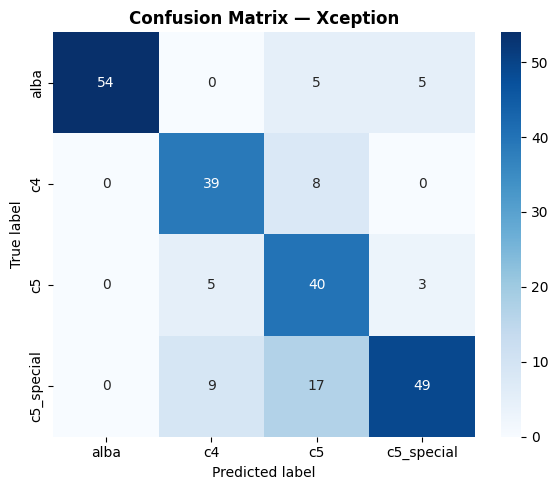

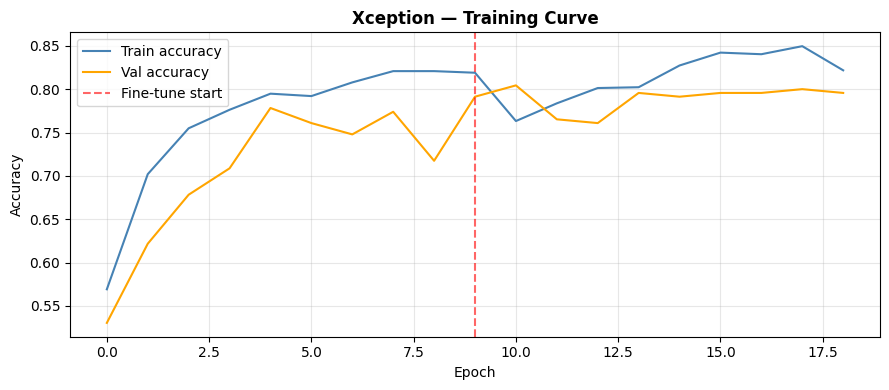

✅ Xception — Test Accuracy: 77.78%
✅ Original generators restored


In [ ]:
from tensorflow.keras.applications import Xception

# Xception needs 299x299 — use same inc generators
xc_train_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=30,
    width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.1, zoom_range=0.2,
    horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)
xc_val_gen = ImageDataGenerator(rescale=1./255)

xc_train = xc_train_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'train'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=True, seed=42
)
xc_val = xc_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'val'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)
xc_test = xc_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'test'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)

# Swap generators
_train, _val, _test = train_data, val_data, test_data
train_data, val_data, test_data = xc_train, xc_val, xc_test

xc_model, xc_base = build_model(Xception, 'Xception', input_shape=(299,299,3))
xc_h1, xc_h2      = train_model(xc_model, xc_base, 'Xception')
evaluate_model(xc_model, 'Xception', xc_h1, xc_h2)

# Restore generators
train_data, val_data, test_data = _train, _val, _test
print('✅ Original generators restored')

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ DenseNet201 built — 18,822,468 parameters

TRAINING: DenseNet201
--- Phase 1: Training head (10 epochs) ---
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.4890 - loss: 1.1921 
Epoch 1: val_accuracy improved from None to 0.60870, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 630s 18s/step - accuracy: 0.5868 - loss: 1.0125 - val_accuracy: 0.6087 - val_loss: 0.8551 - learning_rate: 0.0010
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.7673 - loss: 0.6134 
Epoch 2: val_accuracy improved from 0.60870 to 0.72609, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 599s 18s/step - accuracy: 0.7512 - loss: 0.6536 - val_accuracy: 0.7261 - val_loss: 0.6752 - learning_rate: 0.0010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.7809 - loss: 0.5168 
Epoch 3: val_accuracy did not improve from 0.72609
34/34 ━━━━━━━━━━━━━━━━━━━━ 564s 17s/step - accuracy: 0.7827 - loss: 0.5220 - val_accuracy: 0.7261 - val_loss: 0.6301 - learning_rate: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8136 - loss: 0.4733 
Epoch 4: val_accuracy did not improve from 0.72609
34/34 ━━━━━━━━━━━━━━━━━━━━ 549s 16s/step - accuracy: 0.8069 - loss: 0.4905 - val_accuracy: 0.6913 - val_loss: 0.7072 - learning_rate: 0.0010
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8358 - loss: 0.4169 
Epoch 5: val_accuracy improved from 0.72609 to 0.73478, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet


Epoch 5: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 590s 17s/step - accuracy: 0.8329 - loss: 0.4142 - val_accuracy: 0.7348 - val_loss: 0.6014 - learning_rate: 0.0010
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8262 - loss: 0.4096 
Epoch 6: val_accuracy improved from 0.73478 to 0.76087, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5



Epoch 6: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 552s 16s/step - accuracy: 0.8319 - loss: 0.4182 - val_accuracy: 0.7609 - val_loss: 0.4908 - learning_rate: 0.0010
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8541 - loss: 0.3521 
Epoch 7: val_accuracy improved from 0.76087 to 0.81739, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5


...


Epoch 9: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 784s 23s/step - accuracy: 0.8988 - loss: 0.2649 - val_accuracy: 0.8913 - val_loss: 0.2769 - learning_rate: 1.0000e-05
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.8993 - loss: 0.2591 
Epoch 10: val_accuracy did not improve from 0.89130
34/34 ━━━━━━━━━━━━━━━━━━━━ 804s 23s/step - accuracy: 0.8997 - loss: 0.2596 - val_accuracy: 0.8870 - val_loss: 0.2838 - learning_rate: 1.0000e-05
Epoch 11/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9167 - loss: 0.2232 
Epoch 11: val_accuracy improved from 0.89130 to 0.90000, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5



Epoch 11: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 826s 24s/step - accuracy: 0.9090 - loss: 0.2444 - val_accuracy: 0.9000 - val_loss: 0.2801 - learning_rate: 1.0000e-05
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9178 - loss: 0.2322 
Epoch 12: val_accuracy improved from 0.90000 to 0.90870, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5



Epoch 12: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 786s 23s/step - accuracy: 0.9229 - loss: 0.2189 - val_accuracy: 0.9087 - val_loss: 0.2572 - learning_rate: 1.0000e-05
Epoch 13/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9276 - loss: 0.2345 
Epoch 13: val_accuracy did not improve from 0.90870
34/34 ━━━━━━━━━━━━━━━━━━━━ 796s 23s/step - accuracy: 0.9146 - loss: 0.2361 - val_accuracy: 0.8783 - val_loss: 0.3000 - learning_rate: 1.0000e-05
Epoch 14/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9407 - loss: 0.1895 
Epoch 14: val_accuracy did not improve from 0.90870
34/34 ━━━━━━━━━━━━━━━━━━━━ 783s 23s/step - accuracy: 0.9350 - loss: 0.1925 - val_accuracy: 0.8957 - val_loss: 0.2657 - learning_rate: 1.0000e-05
Epoch 15/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9216 - loss: 0.2051 
Epoch 15: val_accuracy did not improve from 0.90870
34/34 ━━━━━━━━━━━━━━━━━━━━ 777s 23s/step - accuracy: 0.


Epoch 16: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 785s 23s/step - accuracy: 0.9294 - loss: 0.1986 - val_accuracy: 0.9130 - val_loss: 0.2562 - learning_rate: 1.0000e-05
Epoch 17/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9195 - loss: 0.2165 
Epoch 17: val_accuracy did not improve from 0.91304
34/34 ━━━━━━━━━━━━━━━━━━━━ 827s 24s/step - accuracy: 0.9201 - loss: 0.2116 - val_accuracy: 0.9043 - val_loss: 0.2441 - learning_rate: 1.0000e-05
Epoch 18/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9249 - loss: 0.1937 
Epoch 18: val_accuracy did not improve from 0.91304
34/34 ━━━━━━━━━━━━━━━━━━━━ 781s 23s/step - accuracy: 0.9285 - loss: 0.2001 - val_accuracy: 0.9130 - val_loss: 0.2407 - learning_rate: 1.0000e-05
Epoch 19/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9386 - loss: 0.1642 
Epoch 19: val_accuracy improved from 0.91304 to 0.92609, saving model to /content/drive/MyDrive/cinnamon_re


Epoch 19: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet201.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 802s 23s/step - accuracy: 0.9359 - loss: 0.1663 - val_accuracy: 0.9261 - val_loss: 0.2236 - learning_rate: 1.0000e-05
Epoch 20/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.9436 - loss: 0.1875 
Epoch 20: val_accuracy did not improve from 0.92609
34/34 ━━━━━━━━━━━━━━━━━━━━ 835s 24s/step - accuracy: 0.9387 - loss: 0.1928 - val_accuracy: 0.9174 - val_loss: 0.2195 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 19.

=== DenseNet201 Test Results ===
              precision    recall  f1-score   support

        alba     1.0000    0.9062    0.9508        64
          c4     0.7636    0.8936    0.8235        47
          c5     0.8333    0.8333    0.8333        48
  c5_special     0.9178    0.8933    0.9054        75

    accuracy                         0.8846       234
   macro avg     0.8787    0.8816    0.8783       234
we

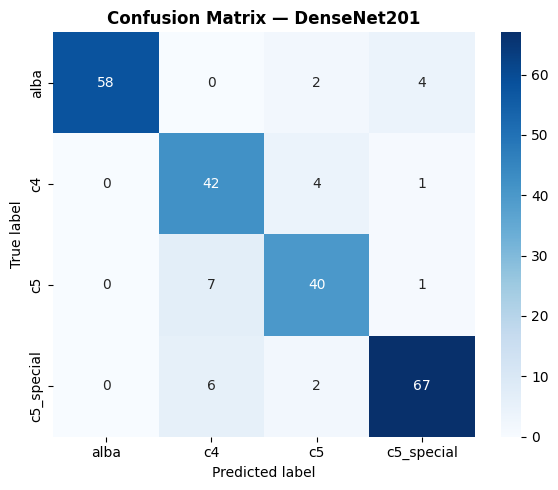

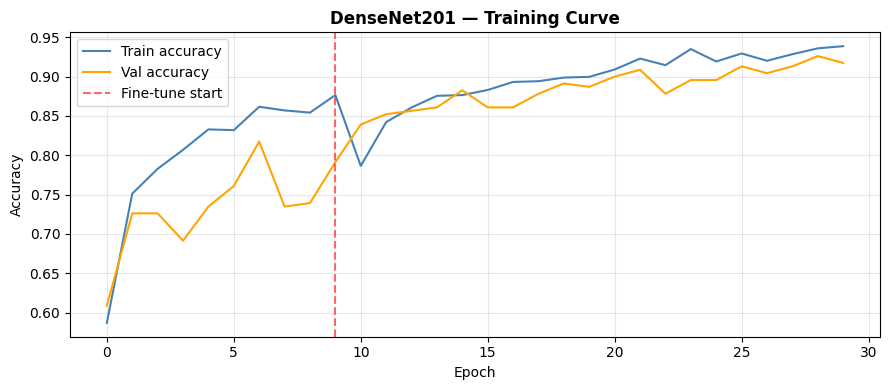

✅ DenseNet201 — Test Accuracy: 88.46%


0.8846153846153846

In [12]:
from tensorflow.keras.applications import DenseNet201

dn201_model, dn201_base = build_model(DenseNet201, 'DenseNet201')
dn201_h1, dn201_h2      = train_model(dn201_model, dn201_base, 'DenseNet201')
evaluate_model(dn201_model, 'DenseNet201', dn201_h1, dn201_h2)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 built — 2,592,068 parameters

TRAINING: MobileNetV2
--- Phase 1: Training head (10 epochs) ---
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4748 - loss: 1.4606
Epoch 1: val_accuracy improved from None to 0.65652, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 388s 11s/step - accuracy: 0.5664 - loss: 1.2409 - val_accuracy: 0.6565 - val_loss: 0.7929 - learning_rate: 0.0010
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6744 - loss: 0.8809
Epoch 2: val_accuracy improved from 0.65652 to 0.72609, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 341s 10s/step - accuracy: 0.6862 - loss: 0.8634 - val_accuracy: 0.7261 - val_loss: 0.6657 - learning_rate: 0.0010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7226 - loss: 0.7472
Epoch 3: val_accuracy improved from 0.72609 to 0.77826, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV2.h5



Epoch 3: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 360s 11s/step - accuracy: 0.7261 - loss: 0.7558 - val_accuracy: 0.7783 - val_loss: 0.5647 - learning_rate: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7603 - loss: 0.5790
Epoch 4: val_accuracy did not improve from 0.77826
34/34 ━━━━━━━━━━━━━━━━━━━━ 347s 10s/step - accuracy: 0.7660 - loss: 0.6139 - val_accuracy: 0.7304 - val_loss: 0.6124 - learning_rate: 0.0010
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7748 - loss: 0.6029
Epoch 5: val_accuracy did not improve from 0.77826
34/34 ━━━━━━━━━━━━━━━━━━━━ 358s 11s/step - accuracy: 0.7864 - loss: 0.5742 - val_accuracy: 0.7478 - val_loss: 0.6127 - learning_rate: 0.0010
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7472 - loss: 0.6868
Epoch 6: val_accuracy did not improve from 0.77826
34/34 ━━━━━━━━━━━━━━━━━━━━ 340s 10s/step - accuracy: 0.7957 - loss: 0.5419 - val


Epoch 10: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 398s 12s/step - accuracy: 0.8245 - loss: 0.4741 - val_accuracy: 0.7913 - val_loss: 0.5130 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

Best val accuracy Phase 1: 0.7913

--- Phase 2: Fine-tuning top 40% layers ---
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5786 - loss: 1.3485
Epoch 1: val_accuracy improved from 0.79130 to 0.81304, saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_MobileNetV2.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 435s 12s/step - accuracy: 0.5905 - loss: 1.2477 - val_accuracy: 0.8130 - val_loss: 0.4694 - learning_rate: 1.0000e-05
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6309 - loss: 0.9694 
Epoch 2: val_accuracy did not improve from 0.81304
34/34 ━━━━━━━━━━━━━━━━━━━━ 427s 12s/step - accuracy: 0.6453 - loss: 0.9278 - val_accuracy: 0.7913 - val_loss: 0.4832 - learning_rate: 1.0000e-05
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7156 - loss: 0.7886
Epoch 3: val_accuracy did not improve from 0.81304
34/34 ━━━━━━━━━━━━━━━━━━━━ 395s 11s/step - accuracy: 0.6992 - loss: 0.8333 - val_accuracy: 0.7913 - val_loss: 0.4967 - learning_rate: 1.0000e-05
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7159 - loss: 0.7390
Epoch 4: val_accuracy did not improve from 0.81304
34/34 ━━━━━━━━━━━━━━━━━━━━ 403s 12s/step - accuracy: 0.6945 - los

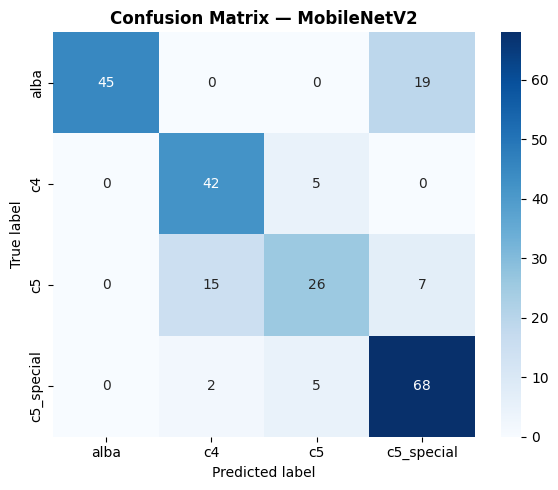

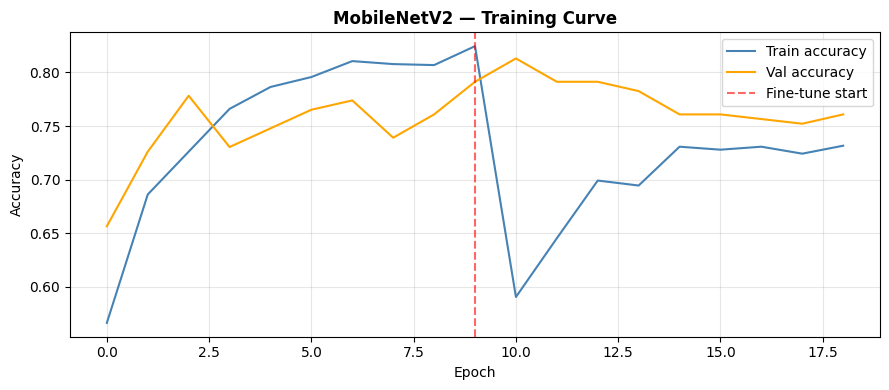

✅ MobileNetV2 — Test Accuracy: 77.35%


0.7735042735042735

In [13]:
from tensorflow.keras.applications import MobileNetV2

mob_model, mob_base = build_model(MobileNetV2, 'MobileNetV2')
mob_h1, mob_h2      = train_model(mob_model, mob_base, 'MobileNetV2')
evaluate_model(mob_model, 'MobileNetV2', mob_h1, mob_h2)